In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df['loan_status'].unique()


array([1, 0])

In [4]:
print("Shape:", df.shape)
print("\nData Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (32581, 12)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df = df.drop_duplicates()

In [6]:
imputer = KNNImputer()

num_cols = df.select_dtypes(include="number").columns

df[num_cols] = imputer.fit_transform(df[num_cols])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [7]:
df = pd.get_dummies(df, columns=[
    'person_home_ownership',
    'loan_intent',
    'loan_grade'
], drop_first=True)


df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y':1, 'N':0})

In [8]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32416 non-null  float64
 1   person_income                32416 non-null  float64
 2   person_emp_length            32416 non-null  float64
 3   loan_amnt                    32416 non-null  float64
 4   loan_int_rate                32416 non-null  float64
 5   loan_status                  32416 non-null  float64
 6   loan_percent_income          32416 non-null  float64
 7   cb_person_default_on_file    32416 non-null  int64  
 8   cb_person_cred_hist_length   32416 non-null  float64
 9   person_home_ownership_OTHER  32416 non-null  bool   
 10  person_home_ownership_OWN    32416 non-null  bool   
 11  person_home_ownership_RENT   32416 non-null  bool   
 12  loan_intent_EDUCATION        32416 non-null  bool   
 13  loan_intent_HOMEIMPRO

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22.0,59000.0,123.0,35000.0,16.02,1.0,0.59,1,3.0,False,...,False,False,True,False,False,False,True,False,False,False
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,0,2.0,False,...,False,False,False,False,True,False,False,False,False,False
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,0,3.0,False,...,False,True,False,False,False,True,False,False,False,False
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,0,2.0,False,...,False,True,False,False,False,True,False,False,False,False
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,1,4.0,False,...,False,True,False,False,False,True,False,False,False,False


In [9]:
conn = sqlite3.connect("creditpathai.db")

df.to_sql("loan_data_cleaned", conn, if_exists="replace", index=False)

conn.close()

print("Cleaned data stored successfully in SQLite.")

Cleaned data stored successfully in SQLite.


In [10]:
conn = sqlite3.connect("creditpathai.db")

df = pd.read_sql("SELECT * FROM loan_data_cleaned", conn)

conn.close()

df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22.0,59000.0,123.0,35000.0,16.02,1.0,0.59,1,3.0,0,...,0,0,1,0,0,0,1,0,0,0
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,0,2.0,0,...,0,0,0,0,1,0,0,0,0,0
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,0,3.0,0,...,0,1,0,0,0,1,0,0,0,0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,0,2.0,0,...,0,1,0,0,0,1,0,0,0,0
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,1,4.0,0,...,0,1,0,0,0,1,0,0,0,0


#Exploratory Data Analysis (EDA)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.747008,6.354100,20.00,23.00,26.00,30.00,144.00
person_income,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
person_emp_length,32416.0,4.770681,4.103324,0.00,2.00,4.00,7.00,123.00
loan_amnt,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32416.0,11.017812,3.125823,5.42,8.32,10.99,13.23,23.22
loan_status,32416.0,0.218688,0.413363,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32416.0,0.170250,0.106812,0.00,0.09,0.15,0.23,0.83
cb_person_default_on_file,32416.0,0.176765,0.381475,0.00,0.00,0.00,0.00,1.00
cb_person_cred_hist_length,32416.0,5.811297,4.059030,2.00,3.00,4.00,8.00,30.00
person_home_ownership_OTHER,32416.0,0.003270,0.057091,0.00,0.00,0.00,0.00,1.00


Target Variable Distribution

loan_status
0.0    25327
1.0     7089
Name: count, dtype: int64


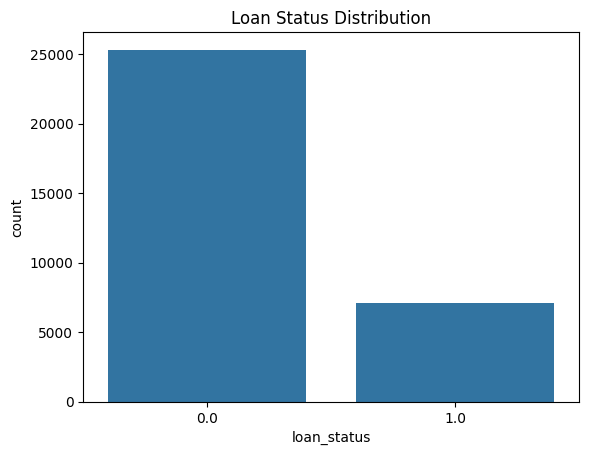

In [12]:
print(df['loan_status'].value_counts())

sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

# Insight:
# Most loans are non-defaulted, showing class imbalance in dataset.

In [13]:
# Percentage distribution
df['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0.0,78.13117
1.0,21.86883


Distribution of Numerical Features

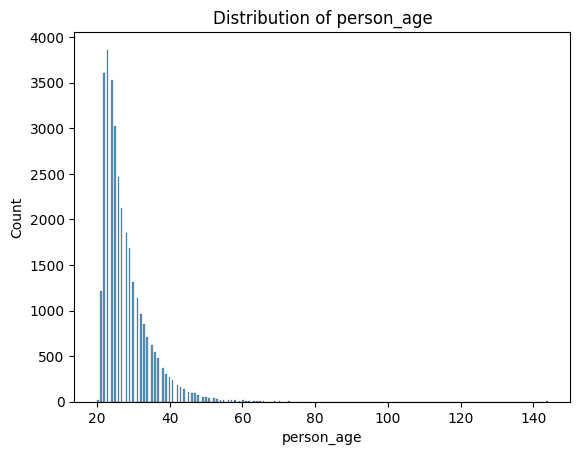

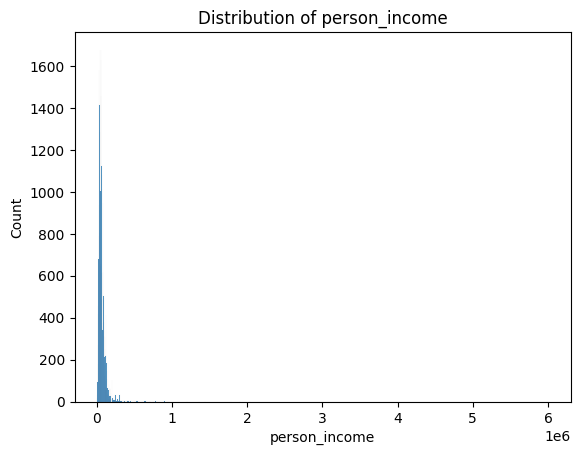

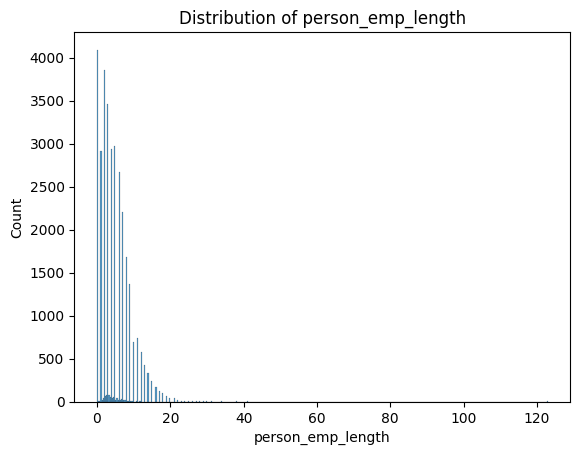

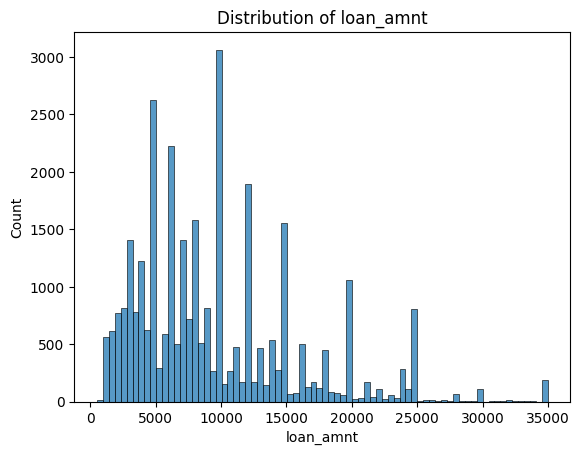

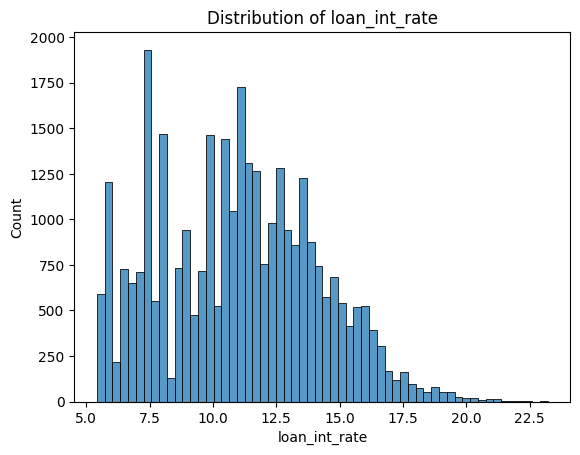

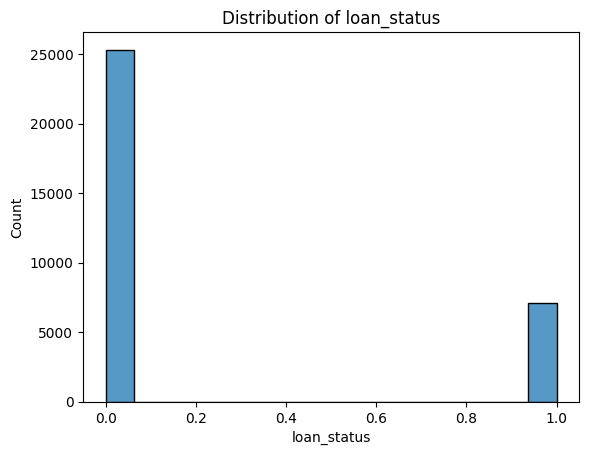

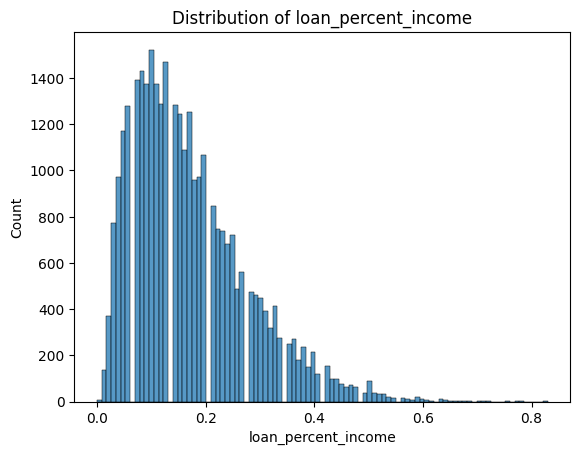

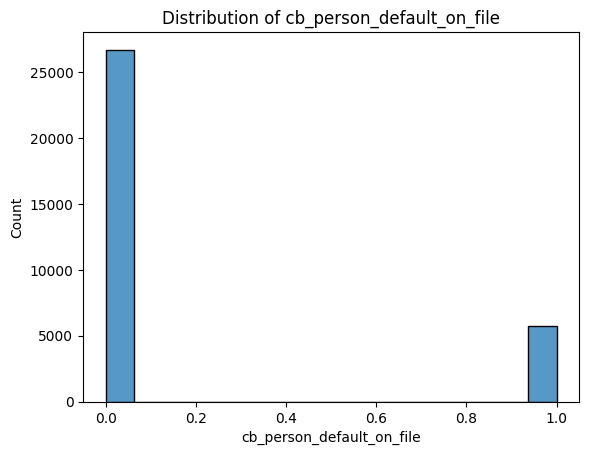

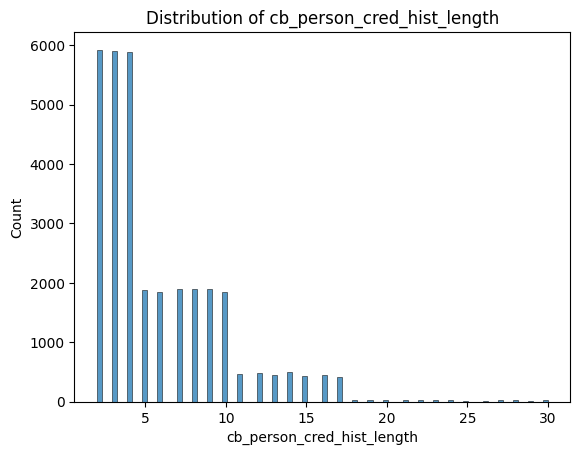

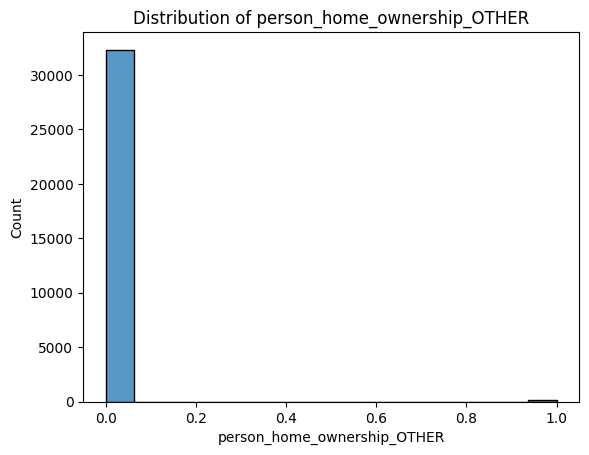

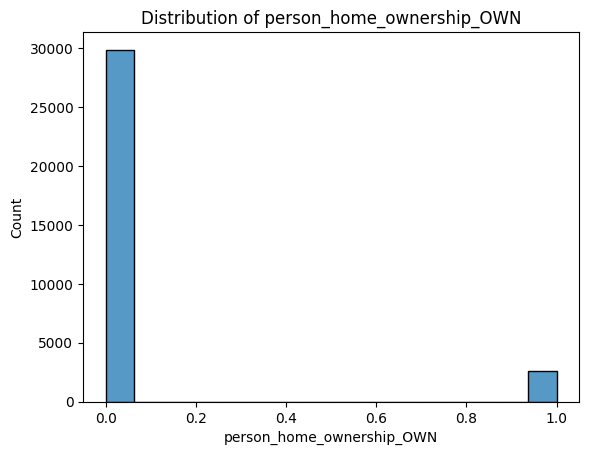

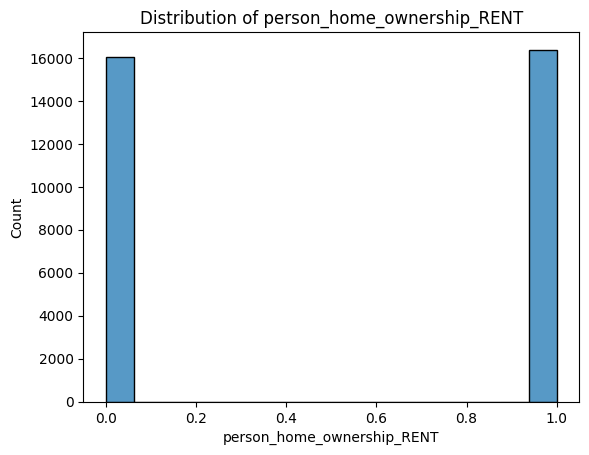

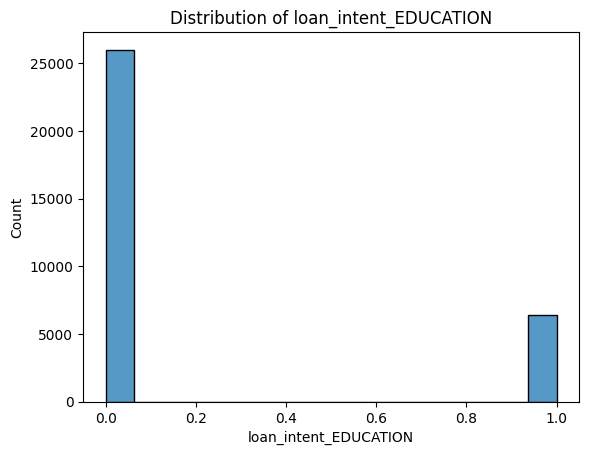

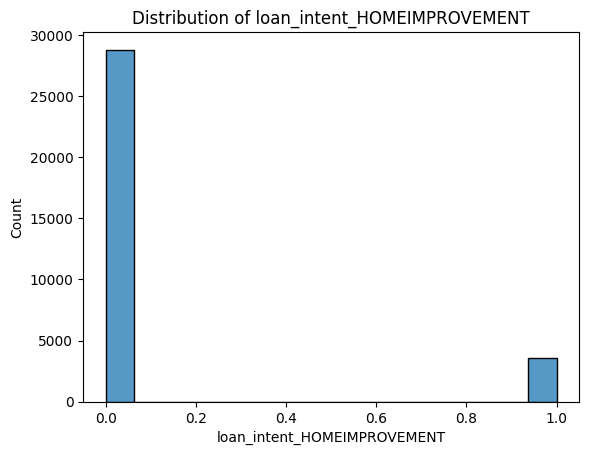

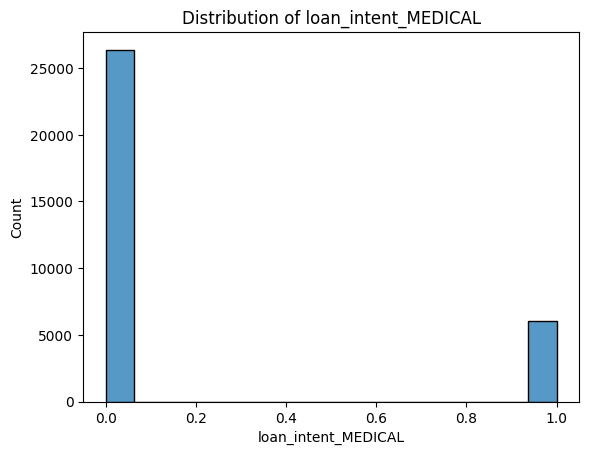

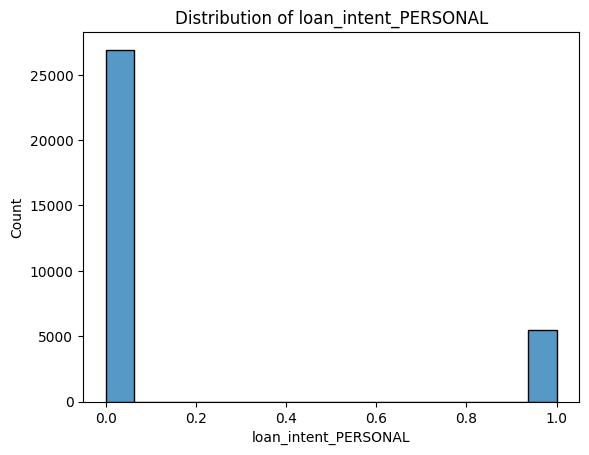

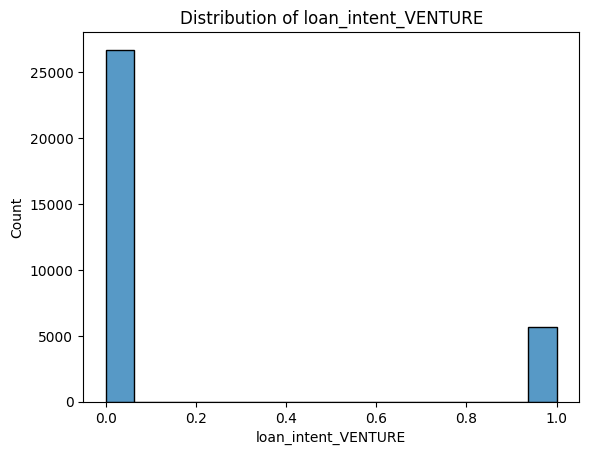

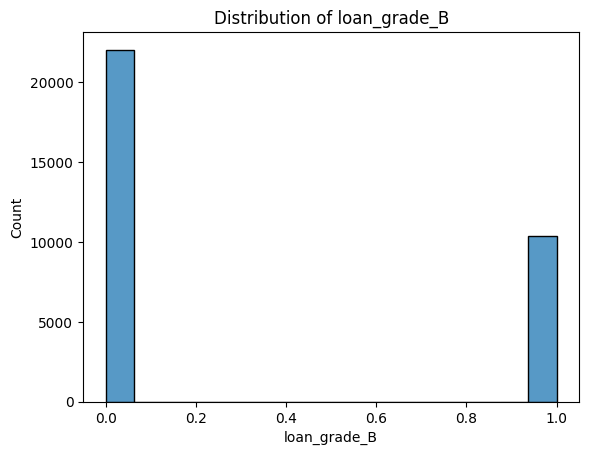

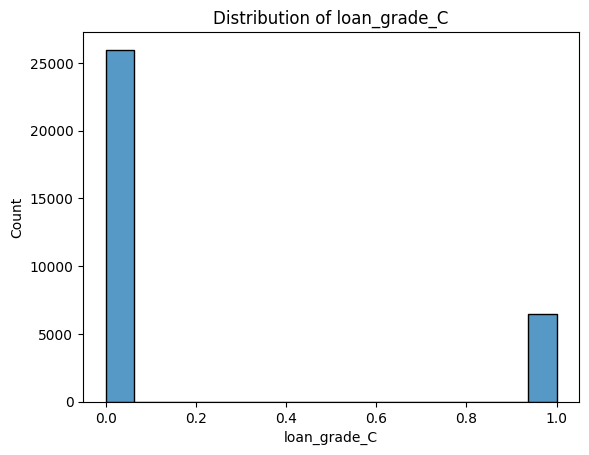

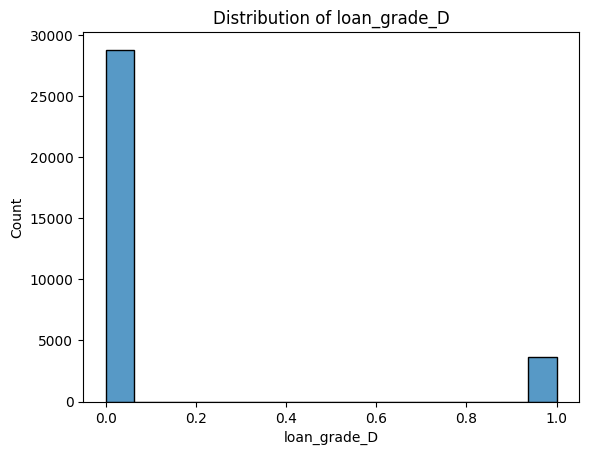

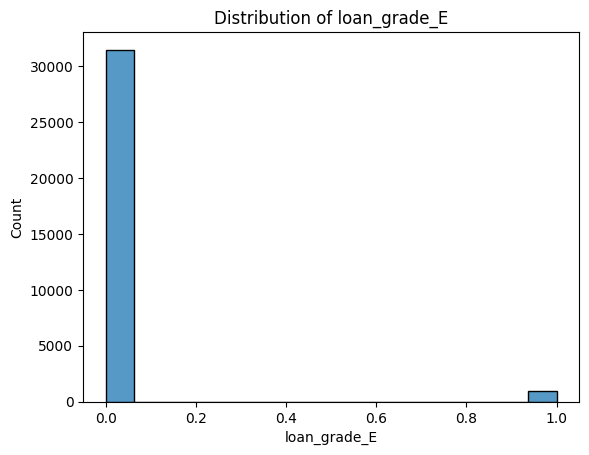

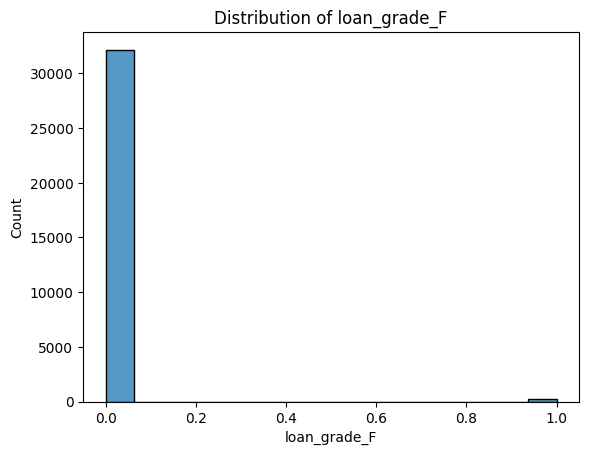

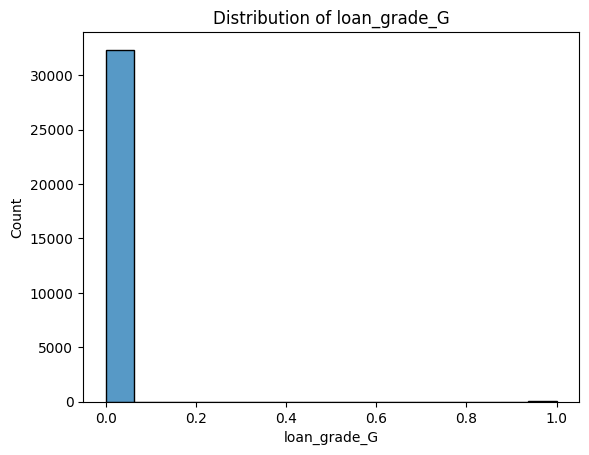

In [14]:
for col in df.select_dtypes(include="number").columns:
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

Outlier Detection


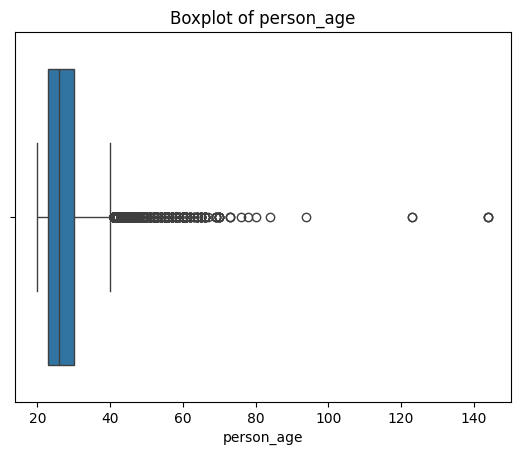

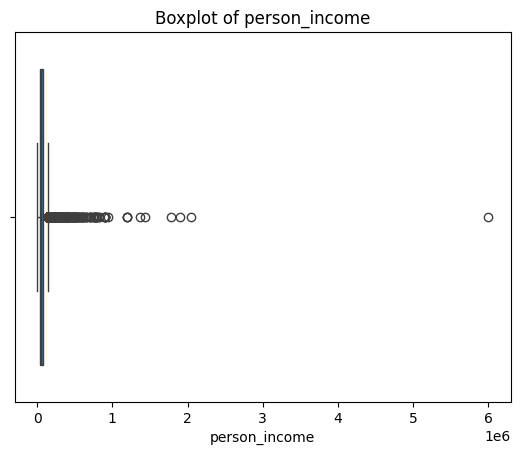

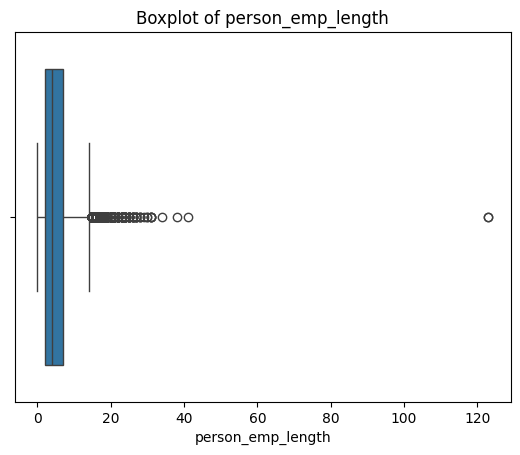

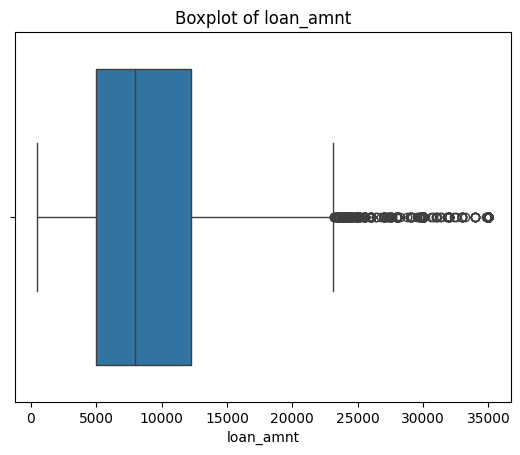

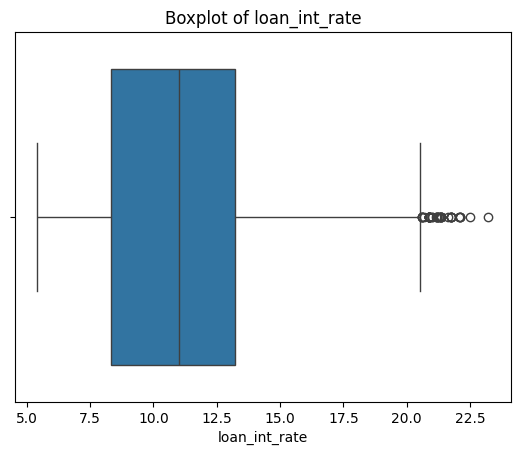

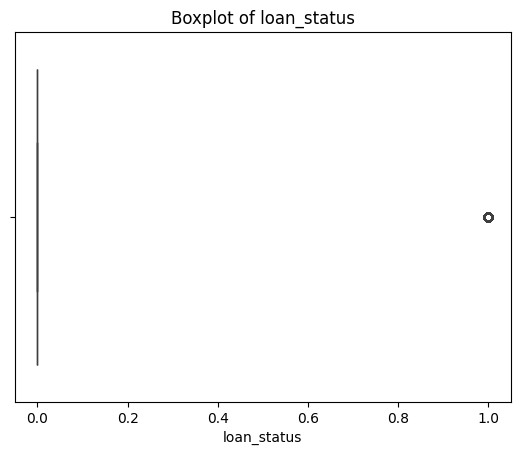

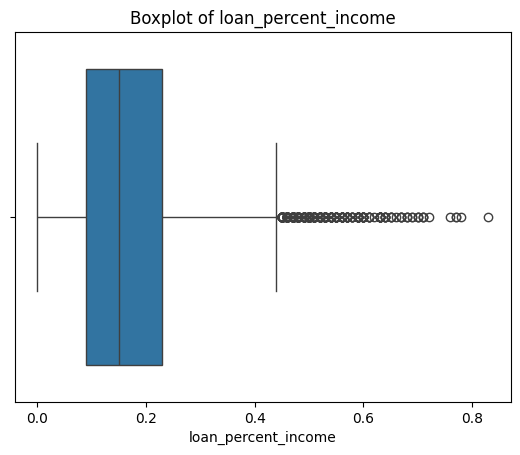

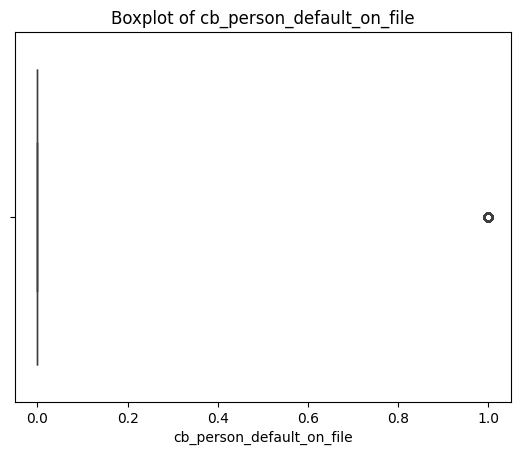

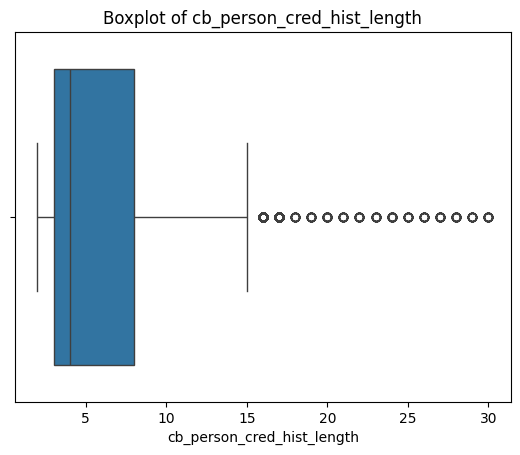

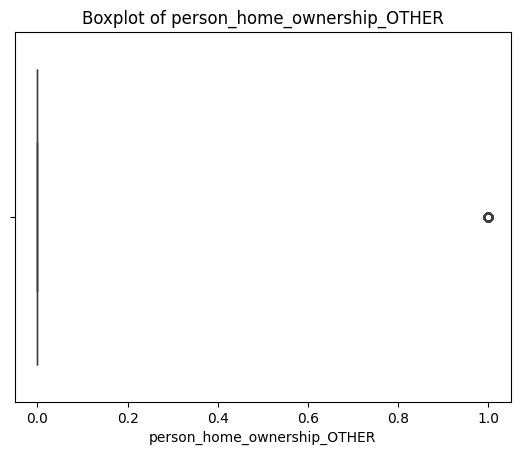

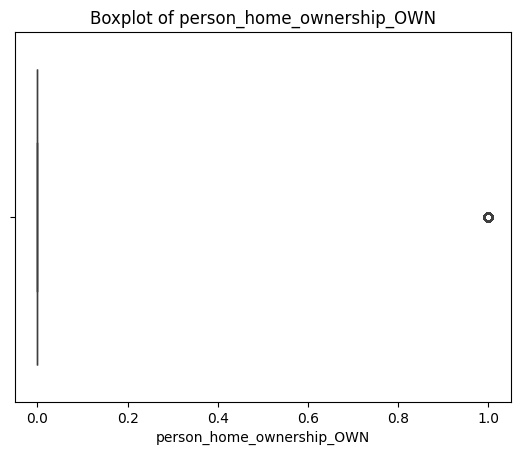

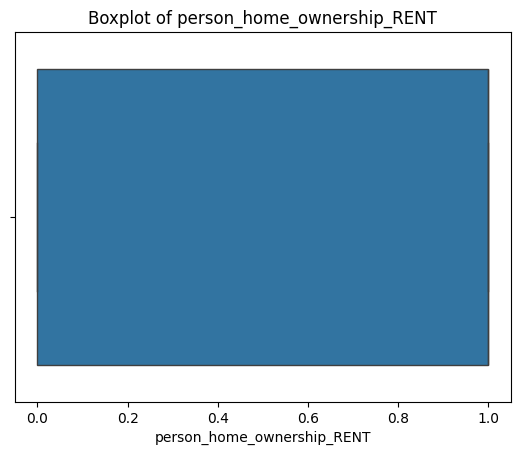

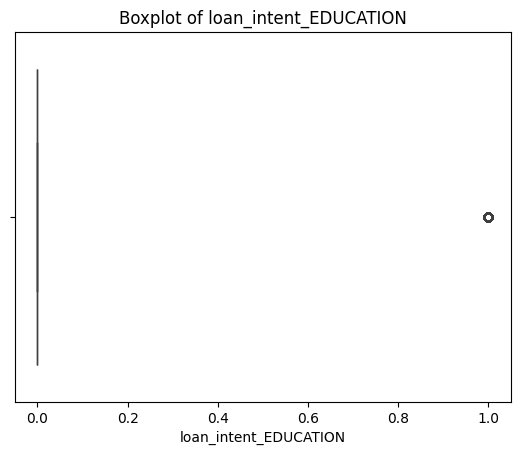

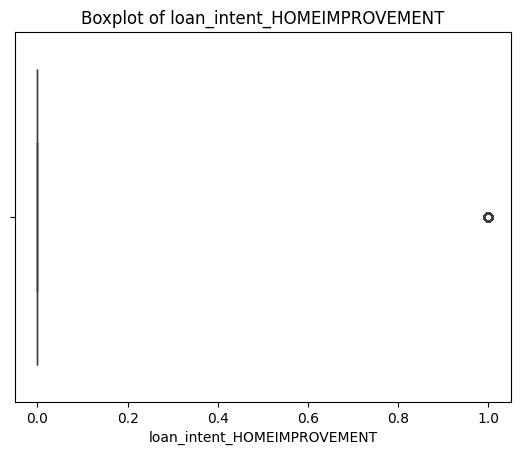

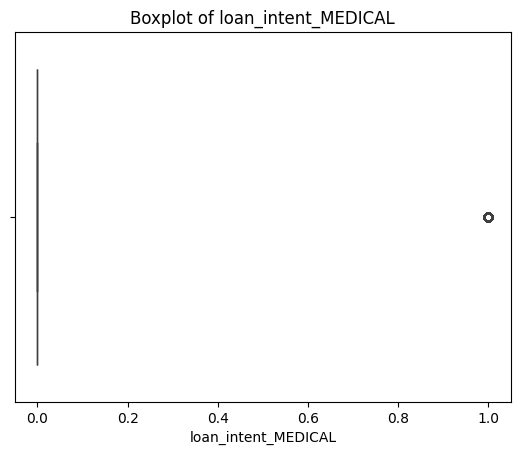

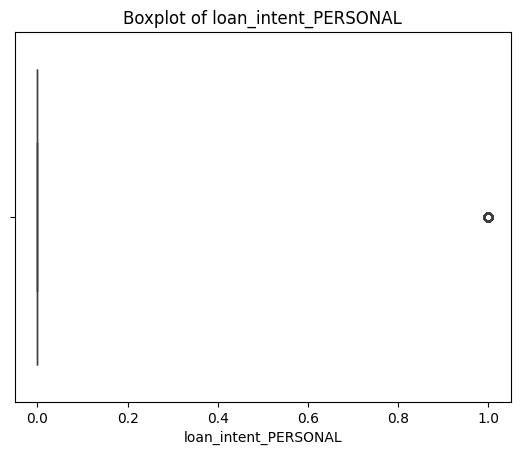

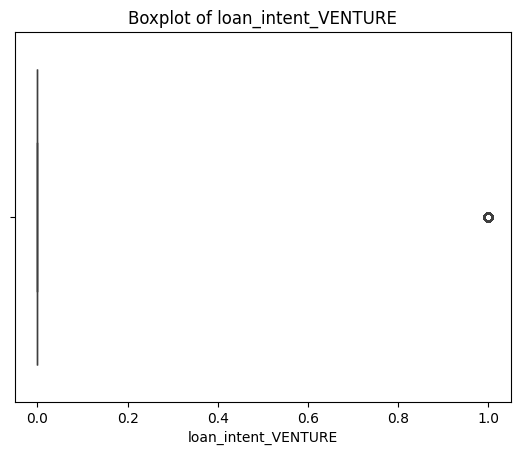

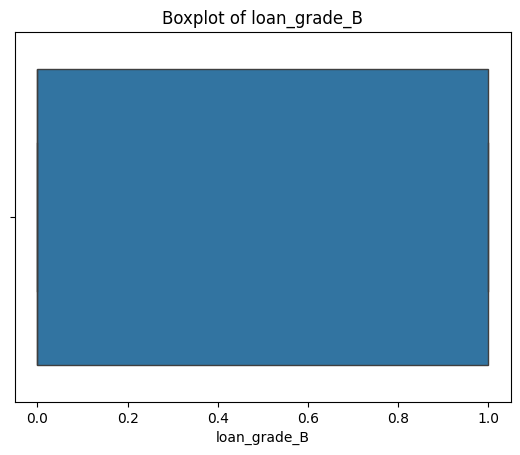

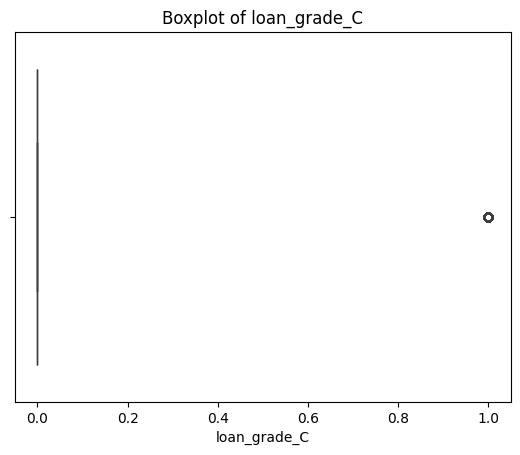

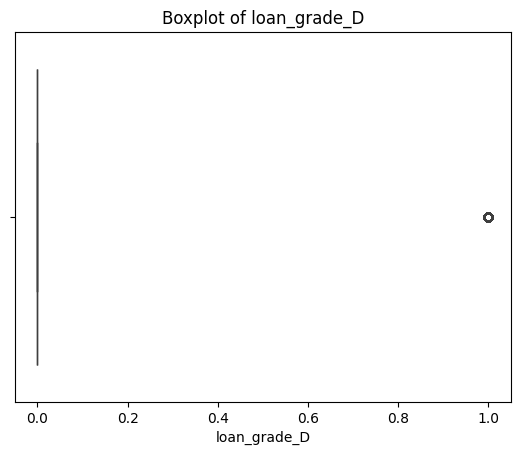

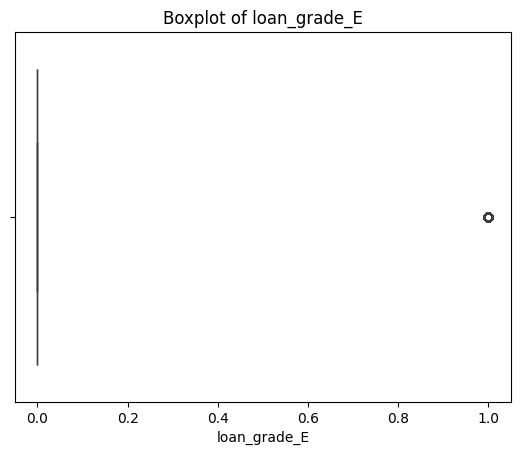

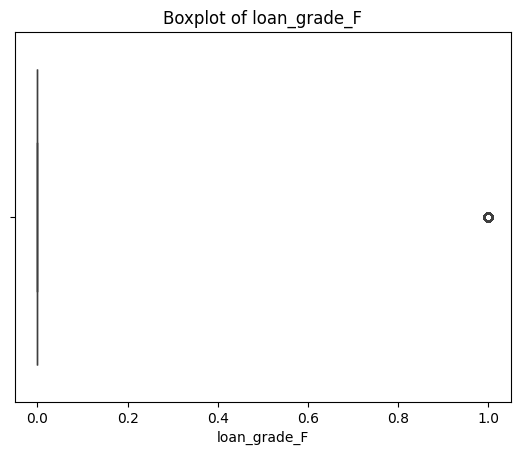

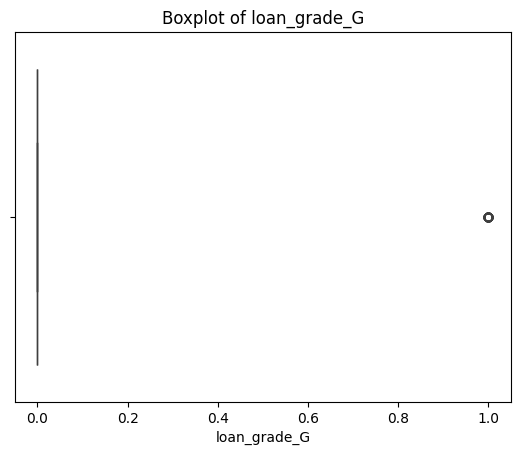

In [15]:
for col in df.select_dtypes(include="number").columns:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Correlation Heatmap

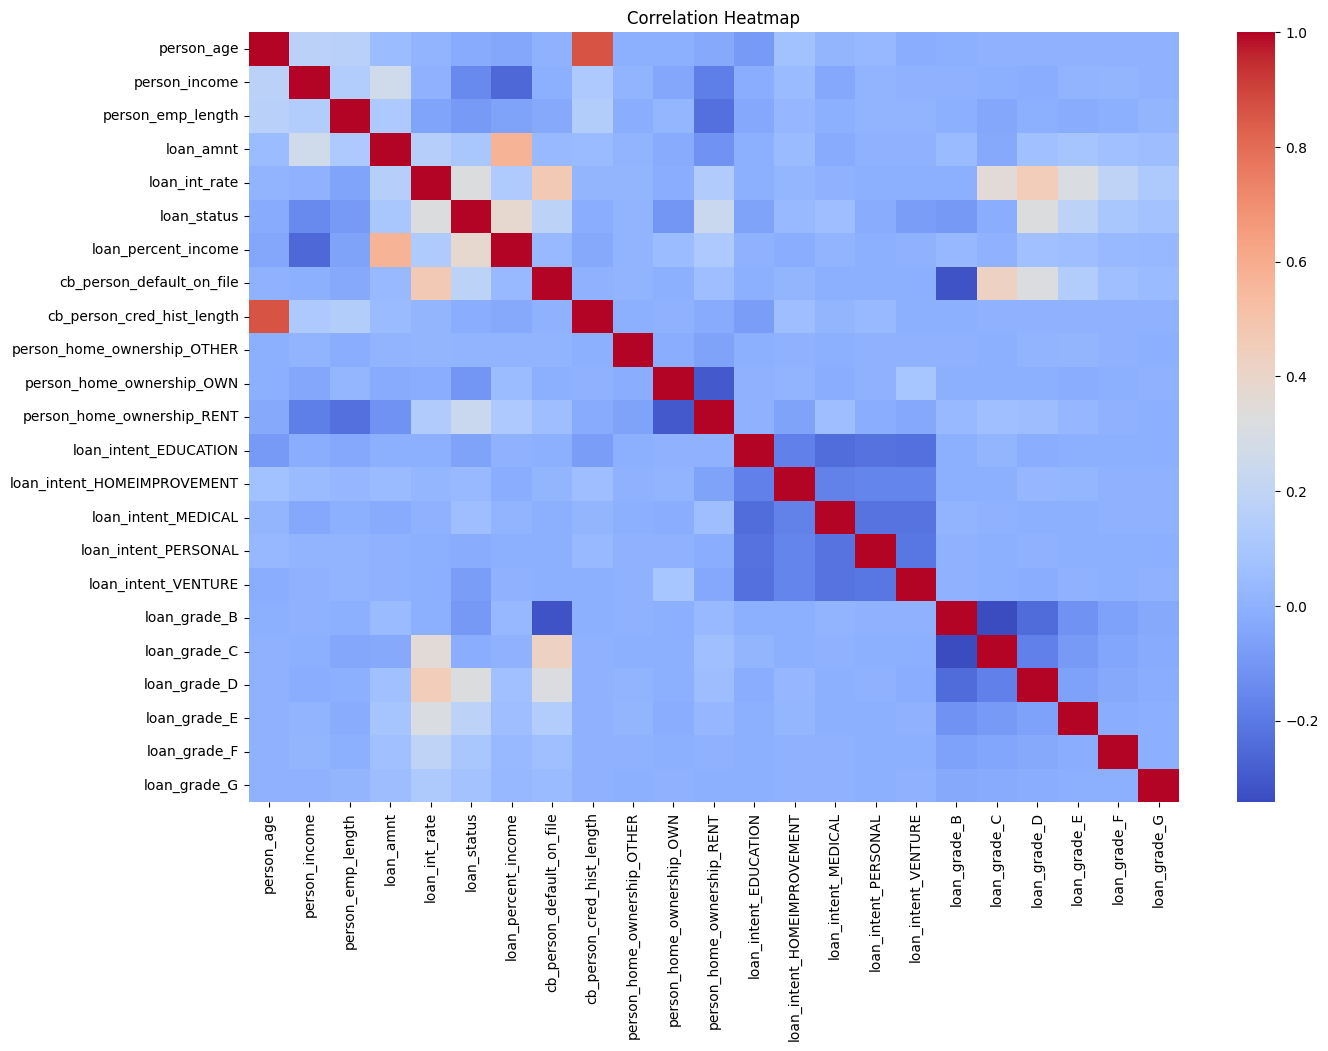

In [16]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22.0,59000.0,123.0,35000.0,16.02,1.0,0.59,1,3.0,0,...,0,0,1,0,0,0,1,0,0,0
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,0,2.0,0,...,0,0,0,0,1,0,0,0,0,0
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,0,3.0,0,...,0,1,0,0,0,1,0,0,0,0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,0,2.0,0,...,0,1,0,0,0,1,0,0,0,0
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,1,4.0,0,...,0,1,0,0,0,1,0,0,0,0


In [18]:
df['loan_status'].unique()

array([1., 0.])

In [ ]:
df['loan_status'].head()

,loan_status
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0


In [19]:
df.to_csv("mileston2processed_credit_risk.csv", index=False)